# Assignment 3 — Authorship Attribution

Predict the author (20 classes) of each fanfiction snippet.

In [1]:
from src.dataloader import load_all

splits = load_all()
for name, (texts, authors) in splits.items():
    print(f"{name}: {len(texts)} snippets, {len(set(authors))} authors")

train: 2138 snippets, 20 authors
dev: 268 snippets, 20 authors
test: 267 snippets, 20 authors


In [2]:
# I had some error that prompted me to run this cell
import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Mikol!\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Mikol!\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [6]:
from src.features import extract_features
from src.model import Classifier

train_texts, train_y = splits["train"]
dev_texts, dev_y = splits["dev"]

train_X = [extract_features(t) for t in train_texts]
dev_X = [extract_features(t) for t in dev_texts]

model = Classifier().train(train_X, train_y)
pred = model.predict(dev_X)

F1 (micro): 0.869
Macro-F1  : 0.851


<Axes: xlabel='Predicted author', ylabel='True author'>

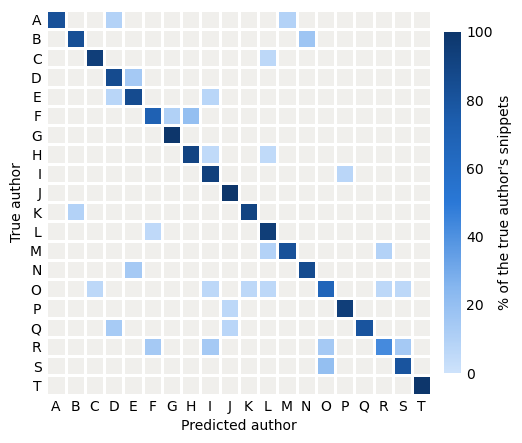

In [7]:
from src.evaluation import f1, macro_f1, confusion

print("F1 (micro):", round(f1(dev_y, pred), 3))
print("Macro-F1  :", round(macro_f1(dev_y, pred), 3))
confusion(dev_y, pred)